# Implémentation originale de Lakhina Entropy

Ce notebook exécute l'adaptation locale de l'algorithme d'origine fournie dans `Lakhina_entropy_IDS.ipynb`.

Il reprend aussi l'exploration visuelle du premier `main`, puis déroule l'algorithme original :
chargement, exploration, entropies, PCA, calibration, figures, évaluation et récapitulatif final.

In [1]:
from copy import deepcopy
from pathlib import Path
import glob

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import classification_report

from analysis.statistics import (
    compute_entropy_preview,
    plot_feature_distributions,
    plot_label_distribution,
    plot_protocol_by_label,
    plot_traffic_over_time,
    print_summary,
)
from main_detection_original import (
    CONFIG as ORIGINAL_CONFIG,
    calculate_anomaly_scores,
    calibrate_thresholds,
    compute_binary_metrics,
    load_splits,
    perform_pca,
    plot_confusion,
    plot_threshold_heatmap,
    predict_anomalies,
    prepare_original_features,
    print_split_overview,
    save_outputs,
)
from preprocessing.loader import clean_dataframe, load_binetflow

In [2]:
CONFIG = deepcopy(ORIGINAL_CONFIG)
RESULTS_DIR = Path(CONFIG['results_dir'])
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def show_saved_figure(filename: str):
    display(Image(filename=str(RESULTS_DIR / filename)))

CONFIG

{'dataset_path': 'data/CTU-13-Dataset/2/*.binetflow',
 'splits_dir': 'data/CTU-13-Dataset/2/splits/',
 'results_dir': 'results/',
 'train_ratio': 0.6,
 'val_ratio': 0.2,
 'use_tcp_only': True,
 'malicious_threshold': 0.0,
 'pca_feature_columns': ('SrcPortEntropy',
  'DestPortEntropy',
  'DestIPEntropy',
  'FlagEntropy'),
 'eigen_threshold': 1e-06,
 'k_minor': 1,
 'threshold_grid_points': 80}

## 1. Exploration du dataset

Cette partie reprend les visualisations du premier `main` pour ne pas perdre le contexte global du dataset.

In [3]:
df_raw = load_binetflow(str(glob.glob(CONFIG['dataset_path'])[0]))
df = clean_dataframe(df_raw)
print_summary(df)
df.head()

data/CTU-13-Dataset/2\capture20110811.binetflow
[INFO] Loading capture20110811.binetflow...
[INFO] 1,808,122 flows chargés. Colonnes : ['StartTime', 'Dur', 'Proto', 'SrcAddr', 'Sport', 'Dir', 'DstAddr', 'Dport', 'State', 'sTos', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes', 'Label']
[INFO] Cleaning: 0 rows removed (0.0%)
DATASET SUMMARY

Total flows                   : 1,808,122
Period                        : 2011-08-11 09:49:35.721274 → 2011-08-11 14:01:11.264754
Captured duration             : 0 days 04:11:35.543480

── Label Distribution ──
  Background  : 1,778,061 (98.34%)  ███████████████████████████████████████
  Botnet      :   20,941 ( 1.16%)  
  Normal      :    9,120 ( 0.50%)  

── Protocols ──
  udp     : 1,485,660 (82.17%)
  tcp     :  293,675 (16.24%)
  icmp    :   23,616 ( 1.31%)
  rtp     :    2,023 ( 0.11%)
  rtcp    :    1,479 ( 0.08%)
  igmp    :    1,241 ( 0.07%)
  arp     :      340 ( 0.02%)
  ipv6-icmp:       44 ( 0.00%)
  udt     :       14 ( 0.00%)
  ipx/spx :    

,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label,Label_raw
0,2011-08-11 09:49:35.721274,2069.973145,udp,203.253.8.233,30533.0,<->,147.32.84.229,13363.0,CON,0.0,0.0,3,197,123,Background,flow=Background-UDP-Established
1,2011-08-11 09:49:35.721530,895.989258,tcp,81.47.154.13,49200.0,<?>,147.32.84.229,13363.0,RPA_PA,0.0,0.0,70,7032,4501,Background,flow=Background
2,2011-08-11 09:49:35.721918,0.000120,udp,147.32.84.229,13363.0,->,78.42.25.171,42988.0,INT,0.0,NaN,3,2858,2858,Background,flow=Background-UDP-Attempt
3,2011-08-11 09:49:35.722518,3561.927246,udp,147.32.84.229,13363.0,<->,113.128.219.130,59790.0,CON,0.0,0.0,63,15770,13419,Background,flow=Background-UDP-Established
4,2011-08-11 09:49:35.723816,0.000000,udp,147.32.84.229,13363.0,->,60.50.167.24,40253.0,INT,0.0,NaN,1,60,60,Background,flow=Background-UDP-Attempt


[INFO] Figure sauvegardée : results\label_distribution.png


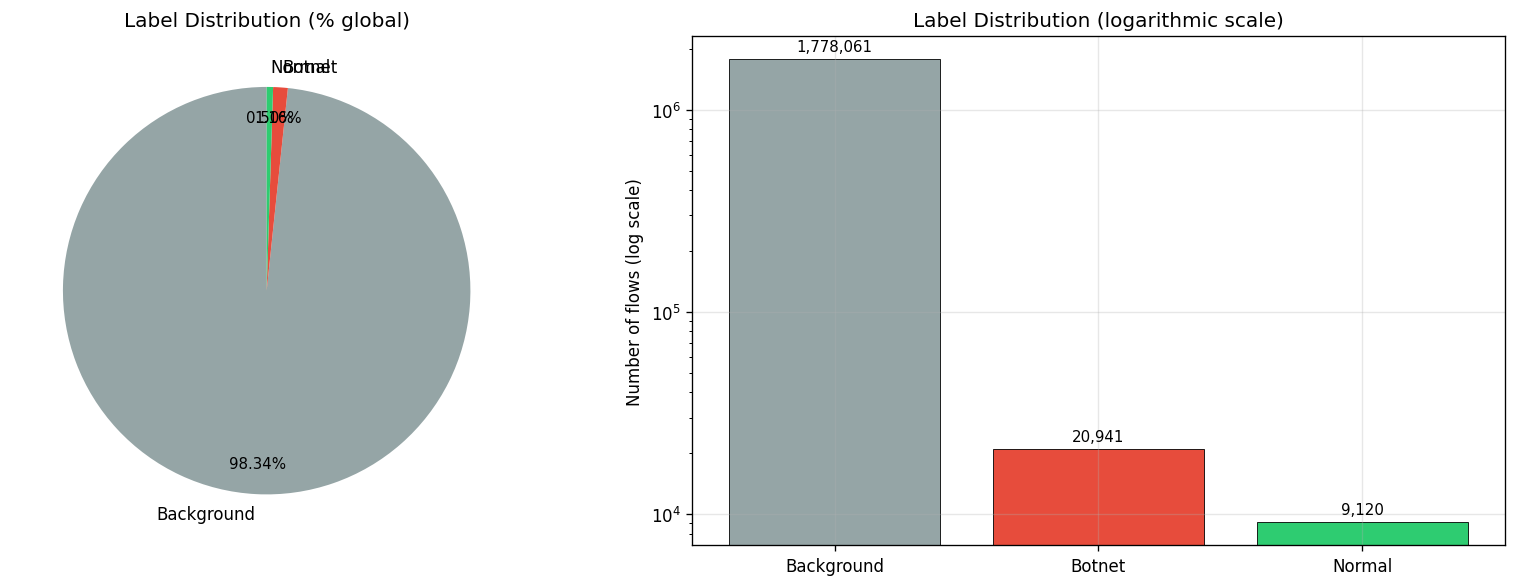

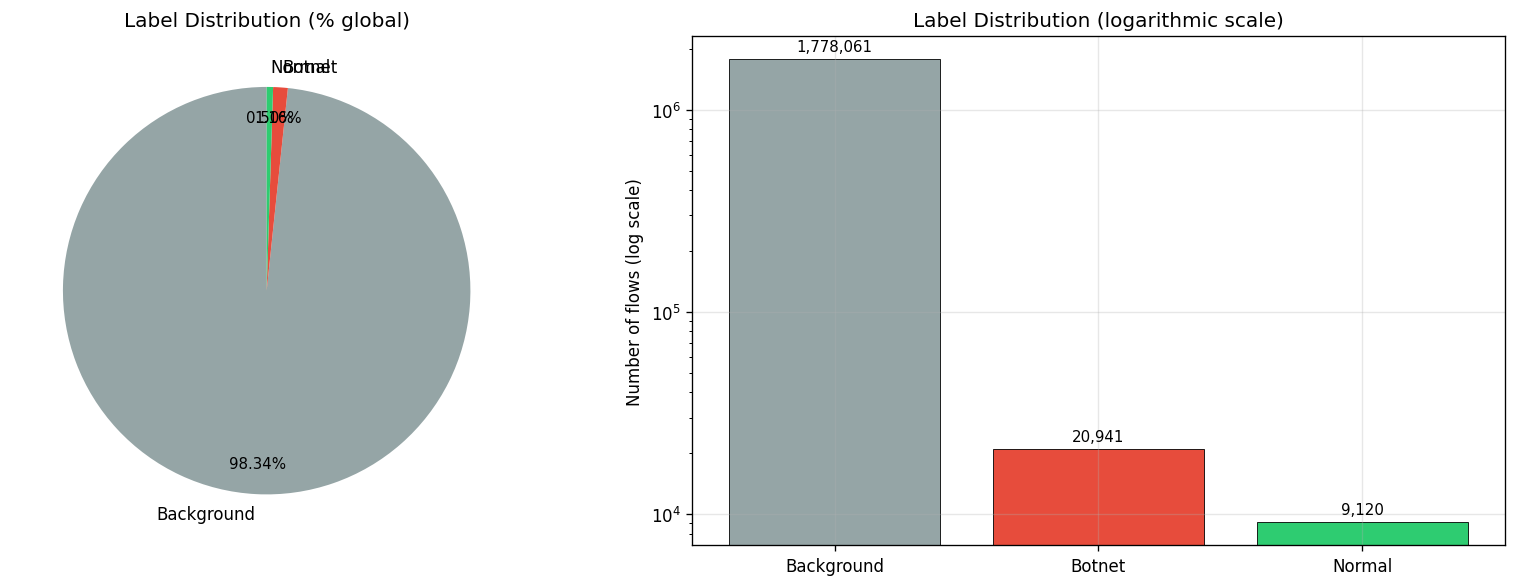

In [4]:
plot_label_distribution(df, str(RESULTS_DIR))
show_saved_figure('label_distribution.png')

[INFO] Figure sauvegardée : results\traffic_over_time.png


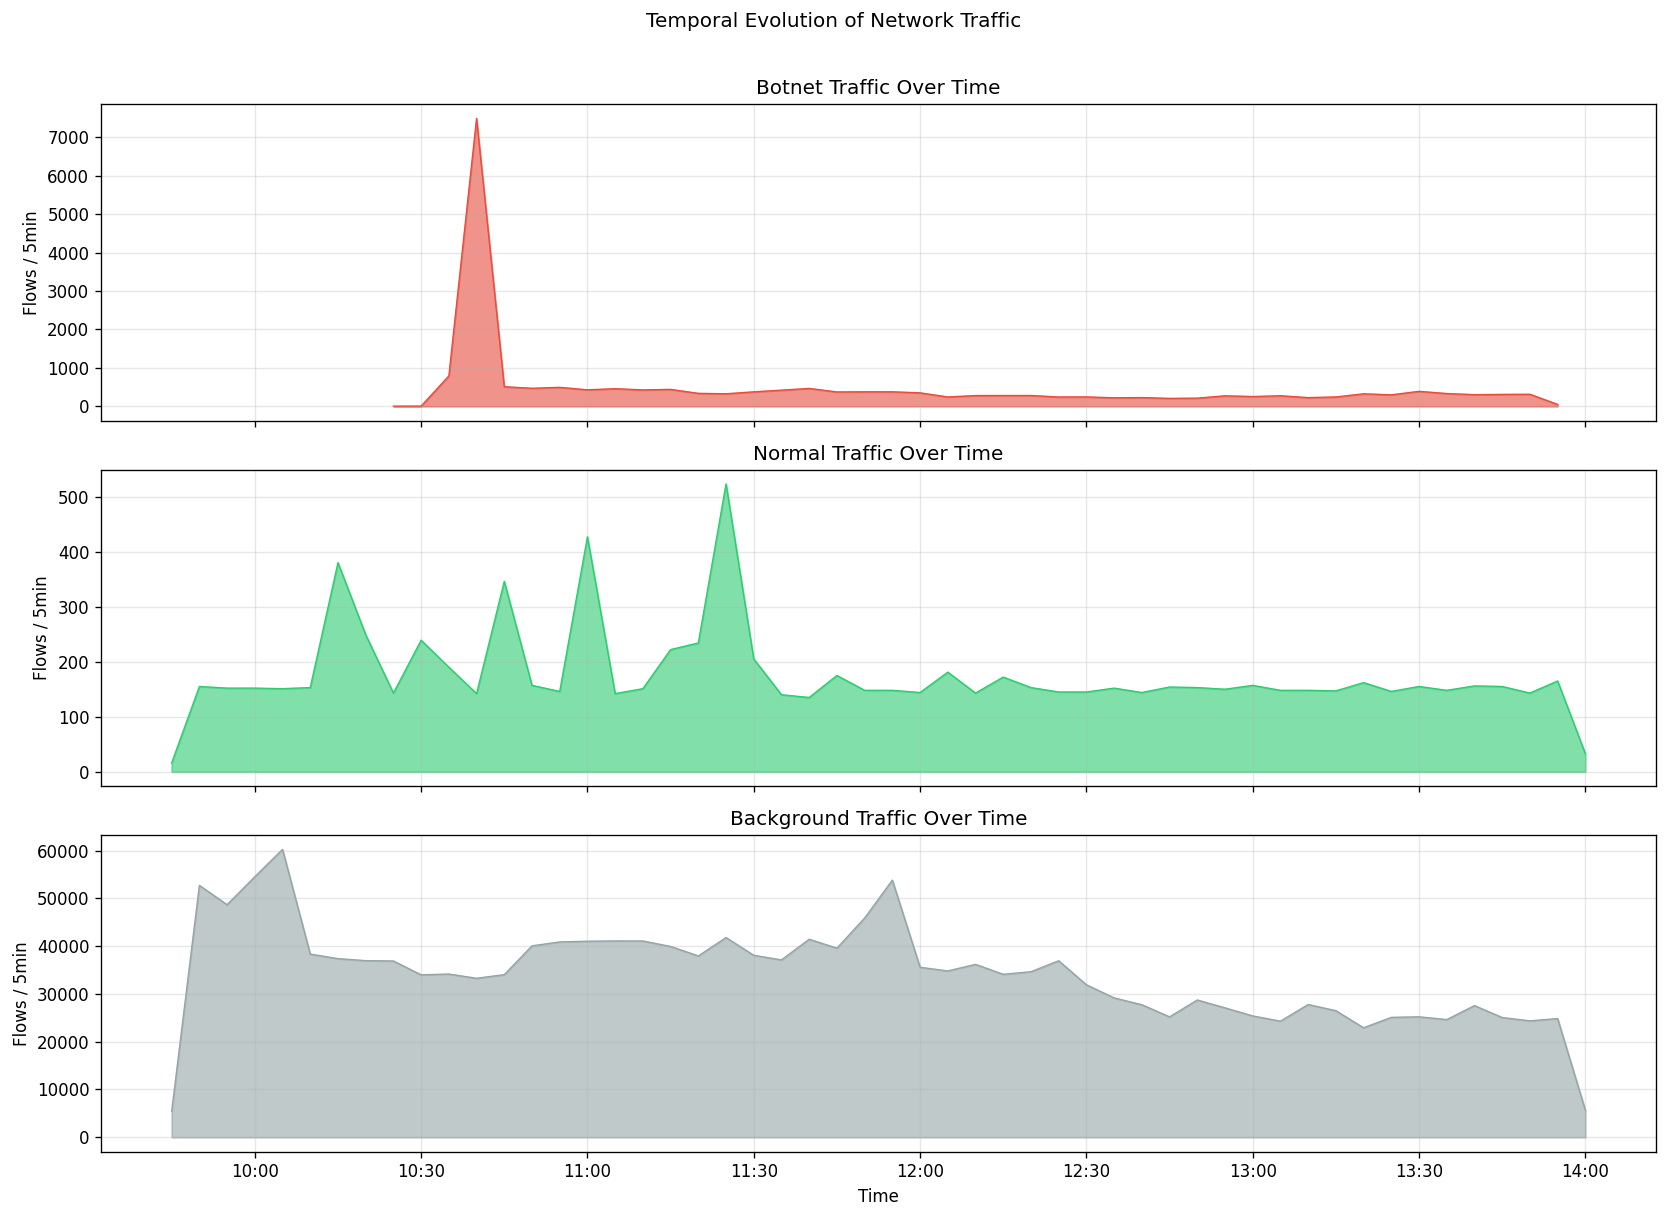

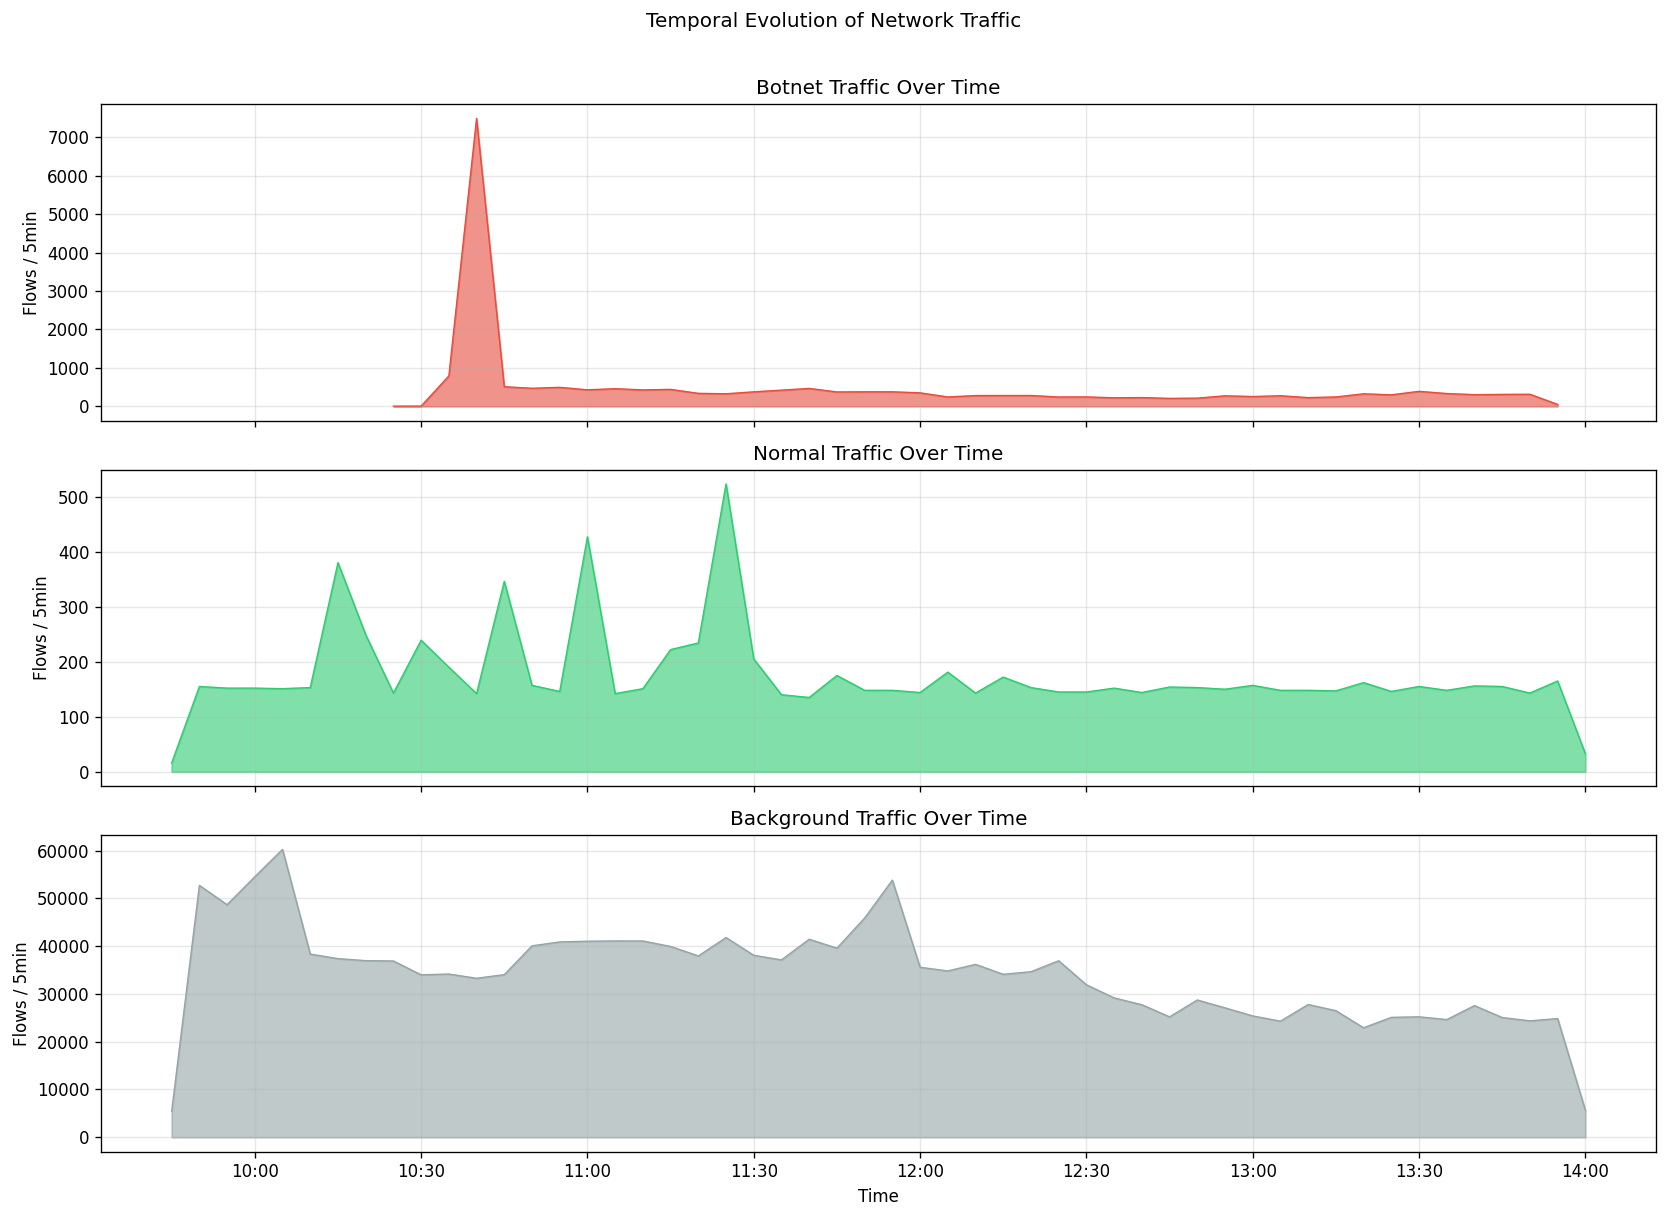

In [5]:
plot_traffic_over_time(df, window='5min', save_dir=str(RESULTS_DIR))
show_saved_figure('traffic_over_time.png')

[INFO] Figure sauvegardée : results\feature_distributions.png


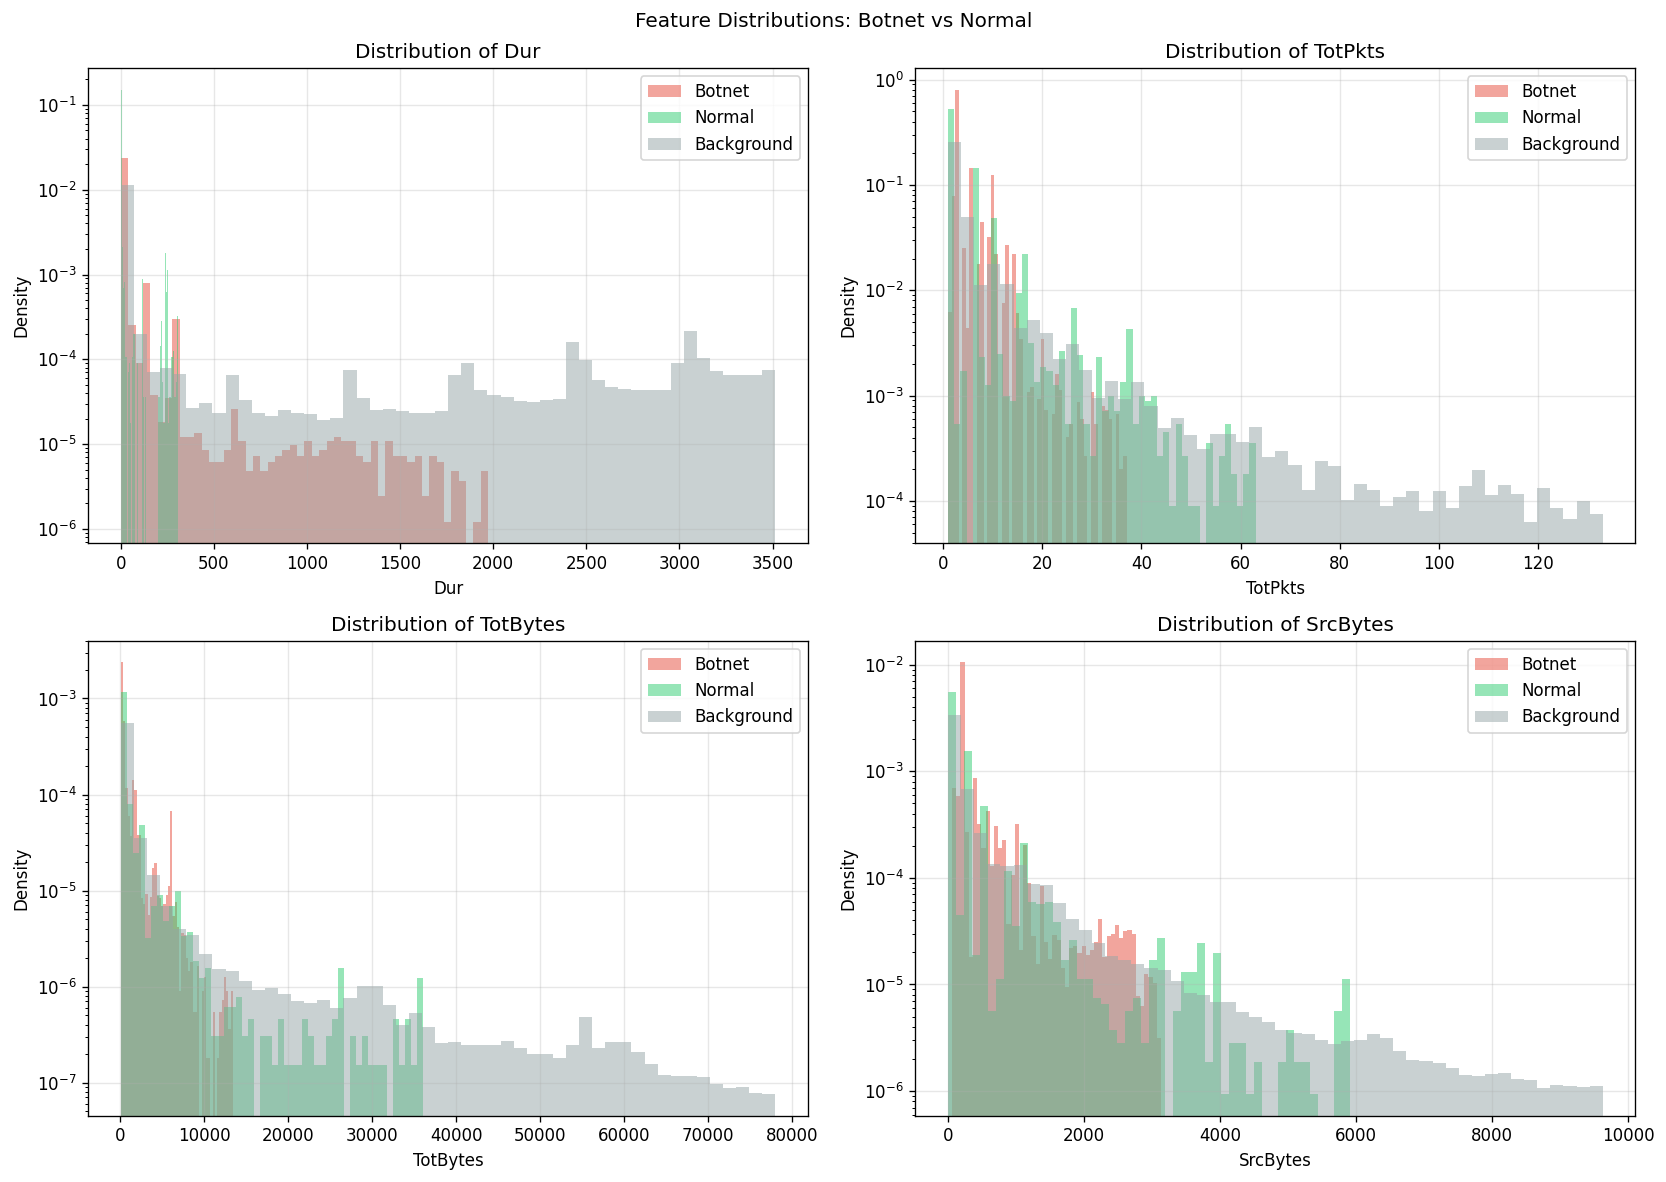

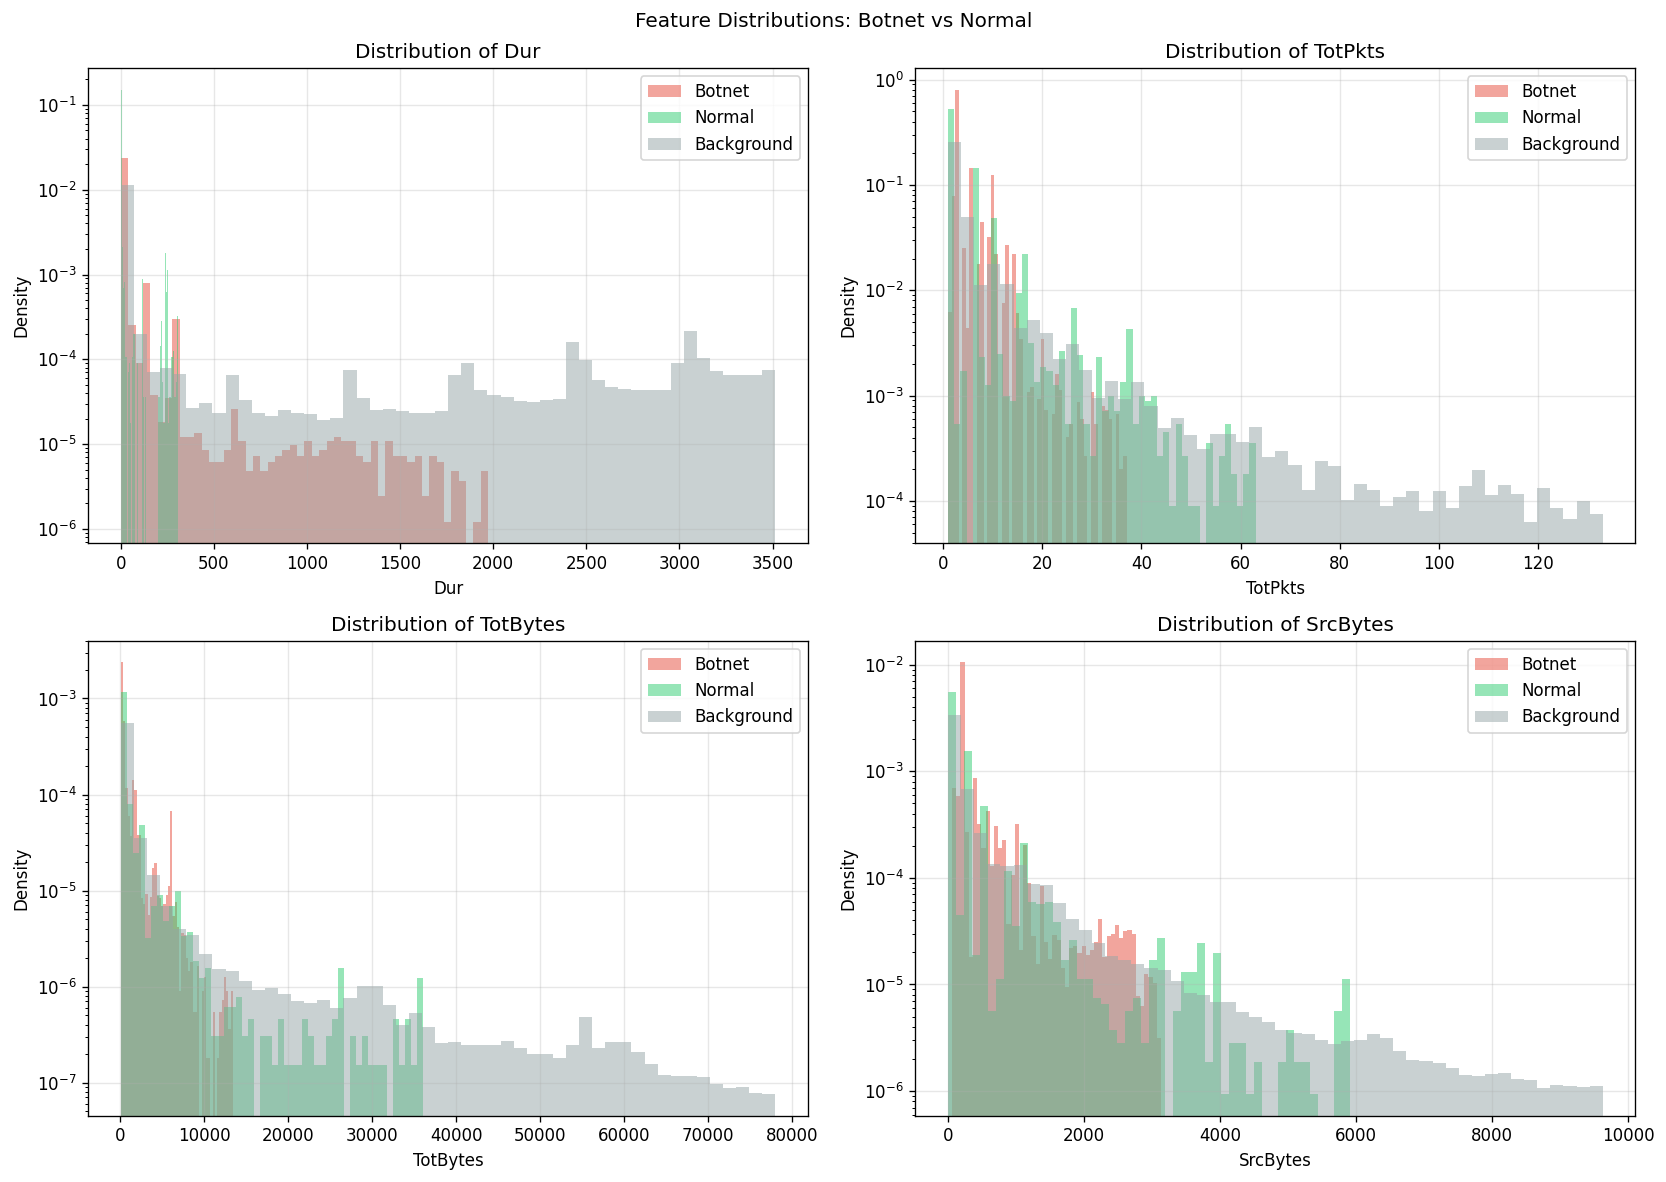

In [6]:
plot_feature_distributions(df, str(RESULTS_DIR))
show_saved_figure('feature_distributions.png')

[INFO] Figure sauvegardée : results\protocol_by_label.png


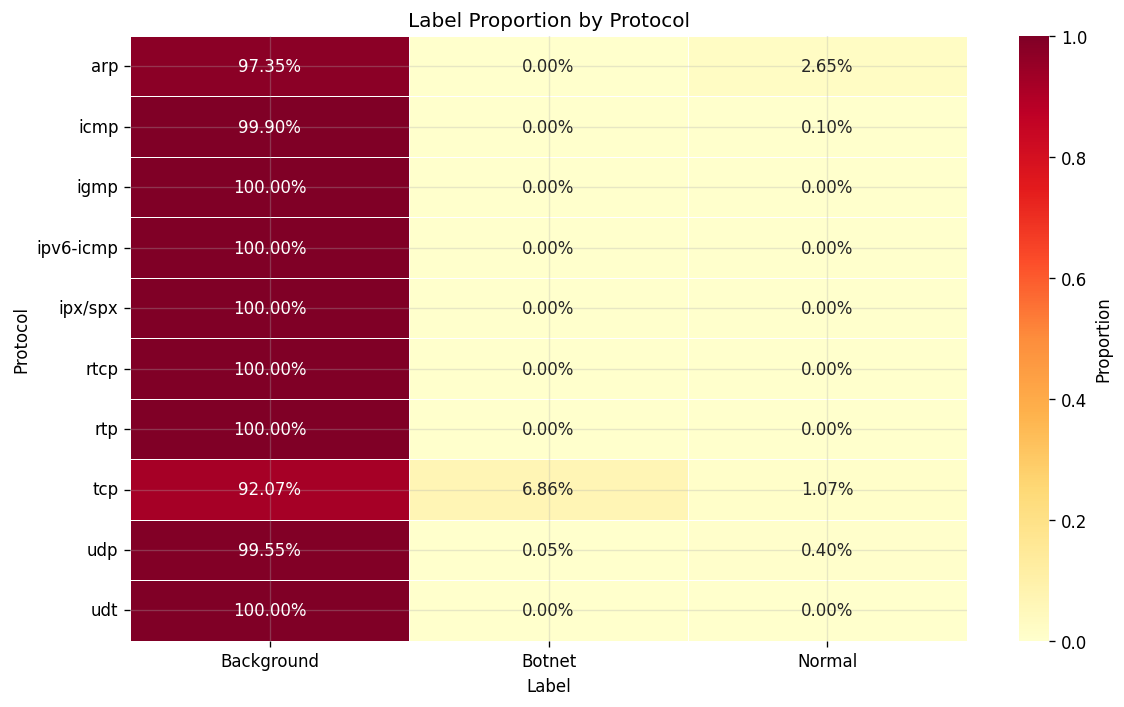

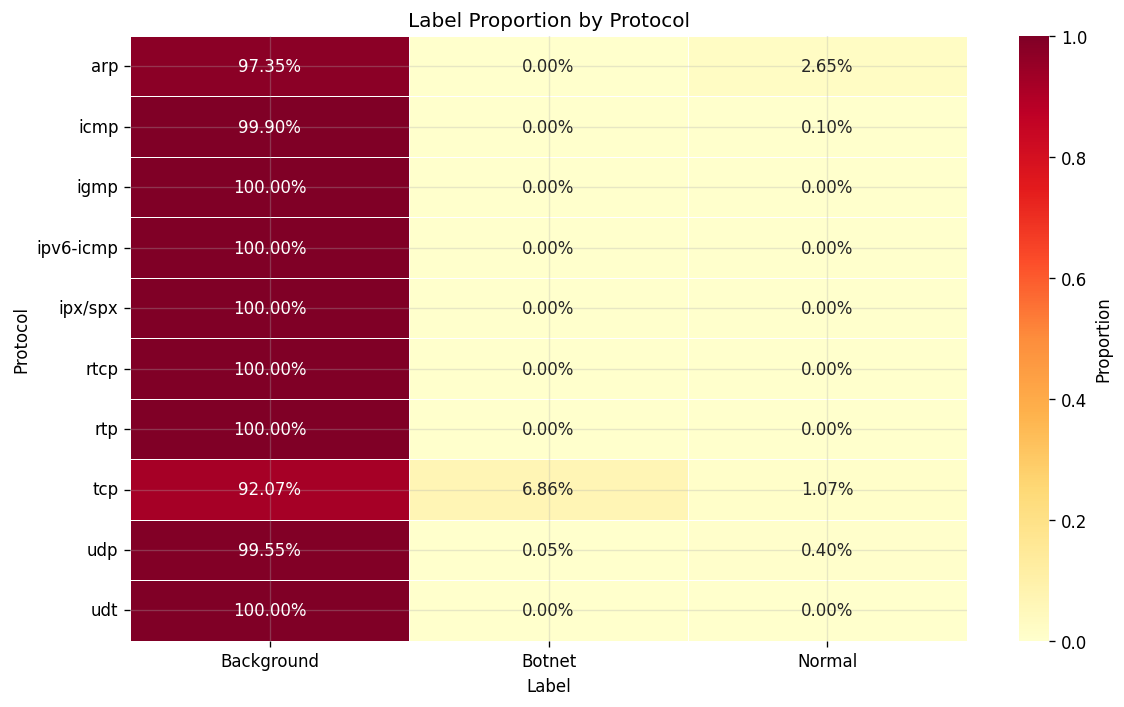

In [7]:
plot_protocol_by_label(df, str(RESULTS_DIR))
show_saved_figure('protocol_by_label.png')

[INFO] Computing entropy preview (may take a few seconds)...
[INFO] Figure sauvegardée : results\entropy_preview.png


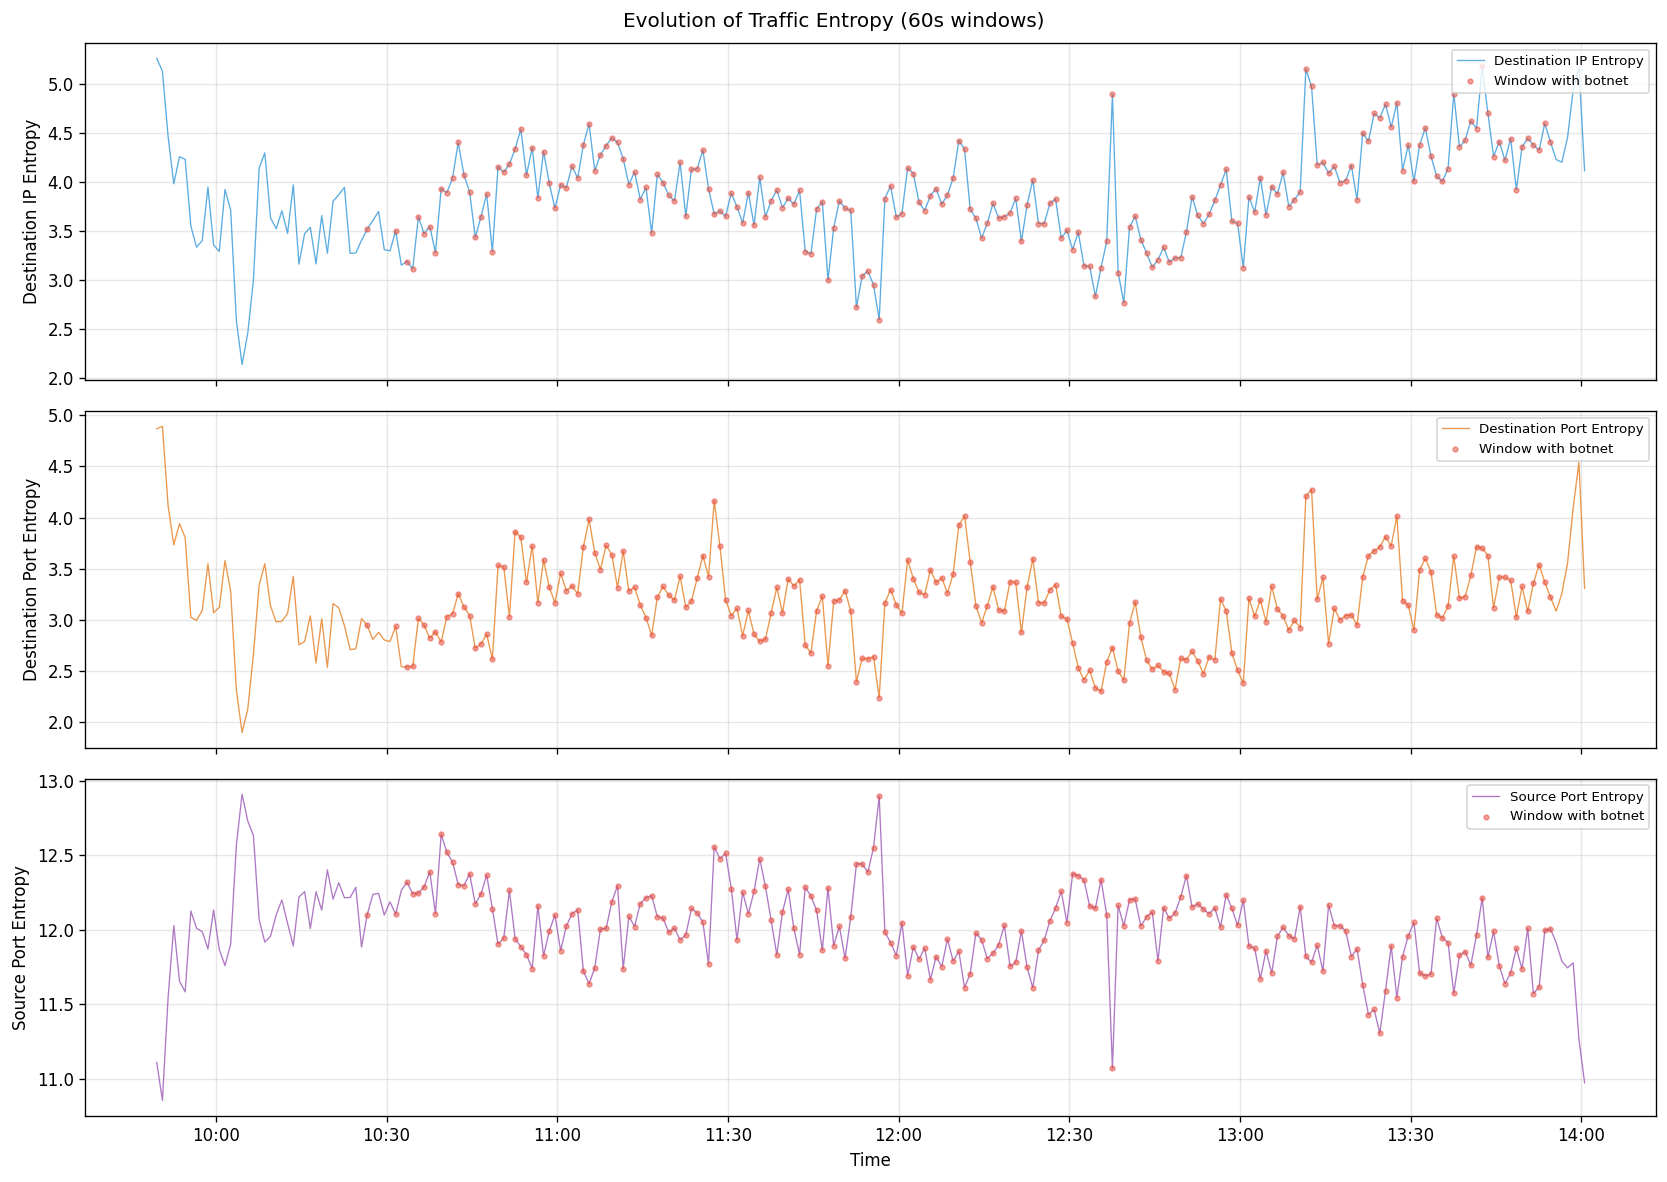

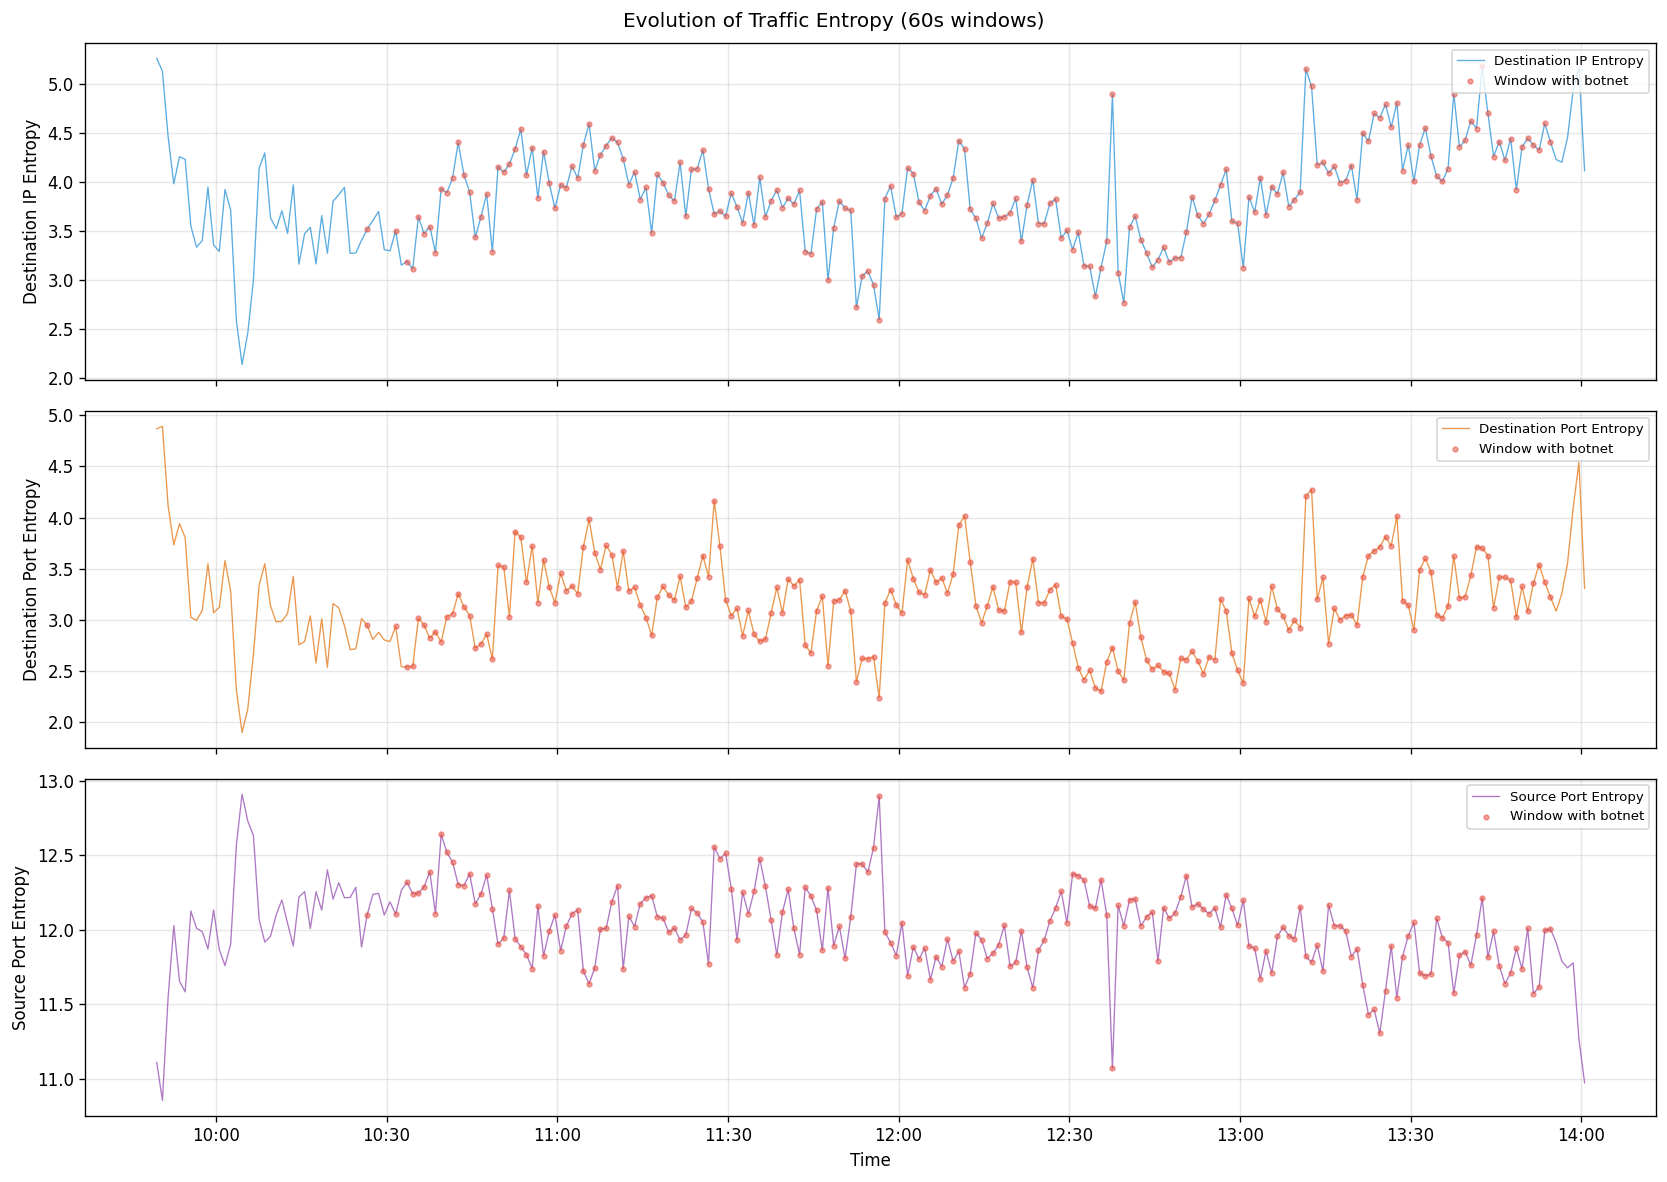

,time,H_dst_ip,H_dst_port,H_src_port,dominant_label,has_botnet,n_flows
0,2011-08-11 09:49:35.721274,5.262545,4.868084,11.108695,Background,False,12228
1,2011-08-11 09:50:35.726957,5.131458,4.893755,10.854234,Background,False,10850
2,2011-08-11 09:51:35.725416,4.465115,4.114256,11.545467,Background,False,9460
3,2011-08-11 09:52:35.725237,3.982237,3.733348,12.027613,Background,False,11700
4,2011-08-11 09:53:35.732010,4.259295,3.941150,11.655404,Background,False,10198


In [8]:
df_entropy_preview = compute_entropy_preview(
    df,
    window_seconds=CONFIG['k_minor'] * 60,
    save_dir=str(RESULTS_DIR),
)
show_saved_figure('entropy_preview.png')
df_entropy_preview.head()

## 2. Chargement des splits locaux

On recharge les mêmes splits temporels que le pipeline principal pour garder une comparaison propre.

In [9]:
df_train, df_val, df_test = load_splits(CONFIG)
print_split_overview(df_train, df_val, df_test)

[LOAD] Fichiers Parquet introuvables.
[LOAD] Rechargement depuis le fichier source...
data/CTU-13-Dataset/2\capture20110811.binetflow
[INFO] Loading capture20110811.binetflow...
[INFO] 1,808,122 flows chargés. Colonnes : ['StartTime', 'Dur', 'Proto', 'SrcAddr', 'Sport', 'Dir', 'DstAddr', 'Dport', 'State', 'sTos', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes', 'Label']
[INFO] Cleaning: 0 rows removed (0.0%)

[INFO] Découpage temporel du dataset :
  Train       : 1,084,873 flows | Botnet:  14,373 ( 1.3%) | Normal:   5,337 ( 0.5%) | Background: 1,065,163 (98.2%)
  Validation  :  361,624 flows | Botnet:   2,820 ( 0.8%) | Normal:   1,663 ( 0.5%) | Background: 357,141 (98.8%)
  Test        :  361,625 flows | Botnet:   3,748 ( 1.0%) | Normal:   2,120 ( 0.6%) | Background: 355,757 (98.4%)
[LOAD] Splits sauvegardés en Parquet avec métadonnée.

── Aperçu des splits ─────────────────────────────────────────────
  Train | total=1,084,873 | Botnet=14,373 | Normal= 5,337 | Background=1,065,163
  Val   |

## 3. Préparation des features de l'implémentation originale

Cette étape suit la logique du notebook d'origine :
- filtrage TCP
- extraction des flags TCP
- agrégation par IP source
- entropies sur ports, IP destination et flags

In [10]:
train_features = prepare_original_features(df_train, CONFIG, label='TRAIN')
val_features = prepare_original_features(df_val, CONFIG, label='VAL')
test_features = prepare_original_features(df_test, CONFIG, label='TEST')

pd.Series(
    {
        'train_ips': len(train_features),
        'val_ips': len(val_features),
        'test_ips': len(test_features),
    }
)

[TRAIN] Flows TCP conservés : 157,888
[TRAIN] IPs agrégées : 7,606
[VAL] Flows TCP conservés : 55,182
[VAL] IPs agrégées : 3,444
[TEST] Flows TCP conservés : 80,605
[TEST] IPs agrégées : 4,119


train_ips    7606
val_ips      3444
test_ips     4119
dtype: int64

In [11]:
entropy_columns = [
    'SrcIP',
    'SrcPortEntropy',
    'DestPortEntropy',
    'DestIPEntropy',
    'FlagEntropy',
    'AggregatedLabel',
]
train_features[entropy_columns].head(10)

,SrcIP,SrcPortEntropy,DestPortEntropy,DestIPEntropy,FlagEntropy,AggregatedLabel
0,81.47.154.13,-0.000000,-0.000000,-0.000000,-0.000000,0
1,147.32.84.229,1.660055,8.326976,8.380175,2.350918,0
2,195.47.34.216,-0.000000,-0.000000,-0.000000,0.918296,0
3,74.125.108.238,-0.000000,-0.000000,-0.000000,-0.000000,0
4,71.194.210.129,-0.000000,-0.000000,-0.000000,-0.000000,0
5,78.80.14.227,-0.000000,-0.000000,-0.000000,-0.000000,0
6,217.153.50.210,-0.000000,-0.000000,-0.000000,1.000000,0
7,147.32.86.166,10.097571,0.716191,6.851796,2.222172,0
8,147.32.86.20,11.872315,-0.000000,1.770837,0.027447,0
9,84.58.61.133,-0.000000,-0.000000,-0.000000,0.918296,0


In [12]:
train_features[list(CONFIG['pca_feature_columns'])].describe()

,SrcPortEntropy,DestPortEntropy,DestIPEntropy,FlagEntropy
count,7606.000000,7606.000000,7606.000000,7606.000000
mean,0.949237,0.341417,0.139008,0.317810
std,1.458230,0.696059,0.734796,0.542341
min,-0.000000,-0.000000,-0.000000,-0.000000
25%,0.000000,0.000000,0.000000,0.000000
50%,-0.000000,-0.000000,-0.000000,-0.000000
75%,1.584963,-0.000000,-0.000000,0.918296
max,13.742022,11.301781,9.508569,3.361805


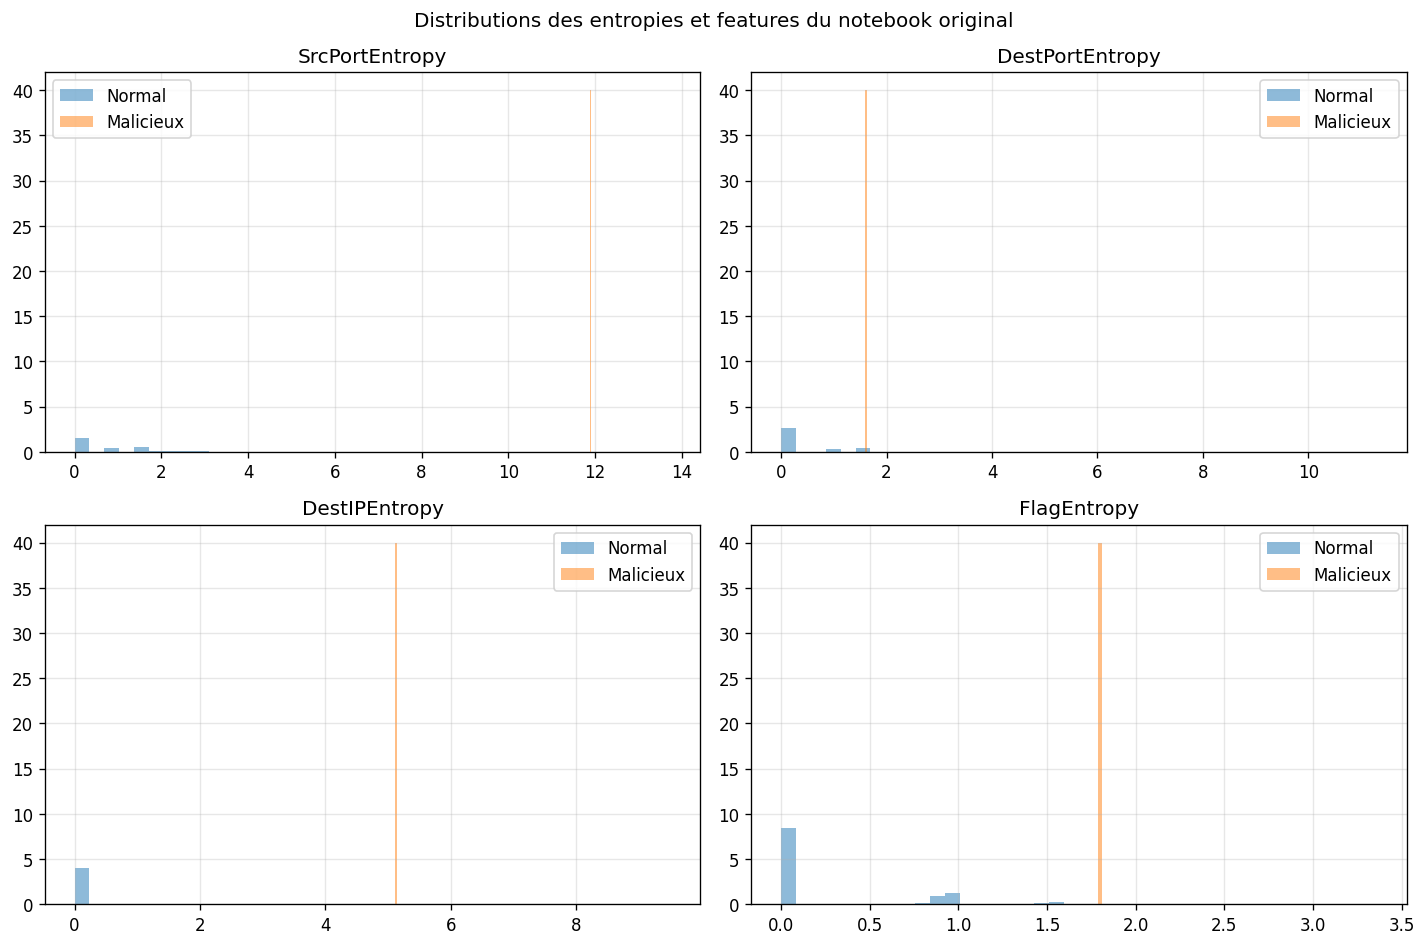

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature_name in zip(axes, CONFIG['pca_feature_columns']):
    subsets = {
        'Normal': train_features[train_features['AggregatedLabel'] == 0][feature_name],
        'Malicieux': train_features[train_features['AggregatedLabel'] == 1][feature_name],
    }
    for label, subset in subsets.items():
        if len(subset) == 0:
            continue
        ax.hist(subset, bins=40, alpha=0.5, density=True, label=label)
    ax.set_title(feature_name)
    ax.legend()

plt.suptitle('Distributions des entropies et features du notebook original')
plt.tight_layout()
plt.show()

## 4. PCA sur les features du notebook original

In [14]:
_, pca_model, significant_components, eigenvalues_sig, train_scaled, scaler = perform_pca(
    train_features,
    CONFIG['pca_feature_columns'],
    eigen_threshold=CONFIG['eigen_threshold'],
)

pd.Series(
    {
        'n_components_total': len(pca_model.explained_variance_),
        'n_components_significatives': significant_components.shape[0],
        'variance_expliquee_totale_pct': float(pca_model.explained_variance_ratio_.sum() * 100),
    }
)

n_components_total                 4.0
n_components_significatives        4.0
variance_expliquee_totale_pct    100.0
dtype: float64

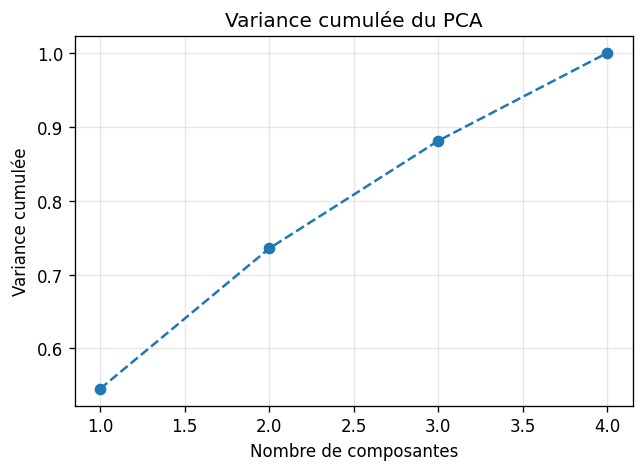

In [15]:
cumulative_variance = pca_model.explained_variance_ratio_.cumsum()

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée')
plt.title('Variance cumulée du PCA')
plt.grid(True)
plt.show()

In [16]:
train_major, train_minor = calculate_anomaly_scores(
    CONFIG['k_minor'],
    train_scaled,
    significant_components,
    eigenvalues_sig,
)

pd.DataFrame(
    {
        'anomaly_score_major': train_major,
        'anomaly_score_minor': train_minor,
    }
).describe()

,anomaly_score_major,anomaly_score_minor
count,7606.000000,7606.000000
mean,3.489284,2.101018
std,13.203001,6.957967
min,0.347737,0.000003
25%,0.347737,0.225538
50%,0.430240,0.225538
75%,3.316304,1.205543
max,598.887364,207.517215


## 5. Calibration des seuils sur validation

In [17]:
val_matrix = val_features[list(CONFIG['pca_feature_columns'])].values
val_scaled = scaler.transform(val_matrix)
val_major, val_minor = calculate_anomaly_scores(
    CONFIG['k_minor'],
    val_scaled,
    significant_components,
    eigenvalues_sig,
)
y_val = val_features['AggregatedLabel'].to_numpy(dtype=int)

best_thresholds, results_df = calibrate_thresholds(
    val_major,
    val_minor,
    y_val,
    grid_points=CONFIG['threshold_grid_points'],
)

plot_threshold_heatmap(results_df, CONFIG['results_dir'])
pd.Series(best_thresholds)

[INFO] Figure sauvegardée : results\threshold_heatmap.png


threshold_major      80.606228
threshold_minor     123.466488
TP                    1.000000
TN                 3432.000000
FP                   11.000000
FN                    0.000000
FPR                   0.003195
Recall                1.000000
Precision             0.083333
Accuracy              0.996806
F1                    0.153846
N_eval             3444.000000
N_botnet              1.000000
N_normal           3443.000000
dtype: float64

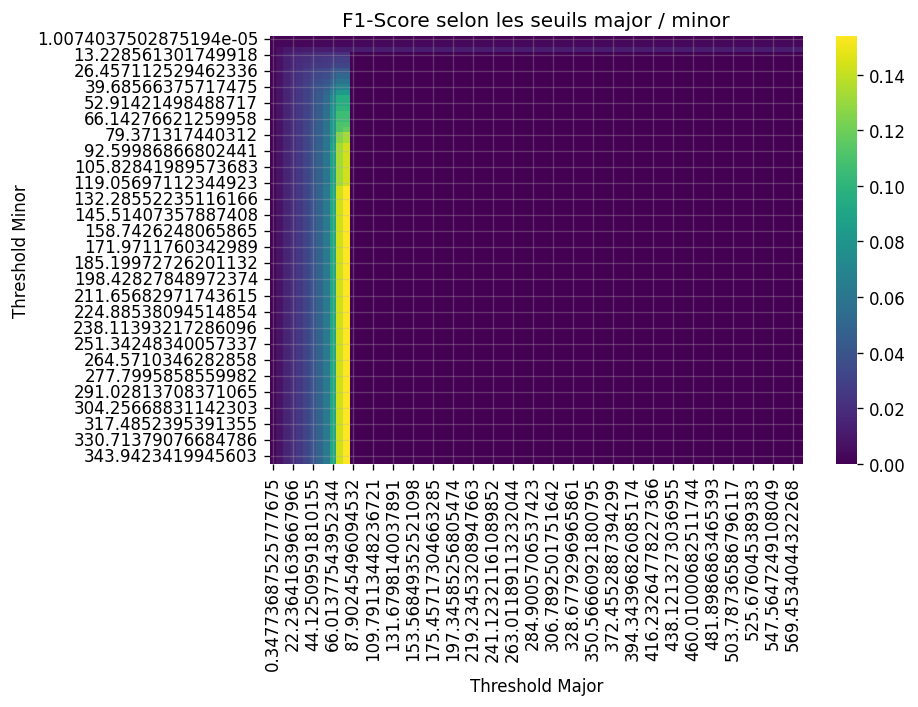

In [18]:
show_saved_figure('threshold_heatmap.png')

## 6. Prédiction sur le test set et évaluation

In [19]:
test_matrix = test_features[list(CONFIG['pca_feature_columns'])].values
test_scaled = scaler.transform(test_matrix)
test_major, test_minor = calculate_anomaly_scores(
    CONFIG['k_minor'],
    test_scaled,
    significant_components,
    eigenvalues_sig,
)
y_test = test_features['AggregatedLabel'].to_numpy(dtype=int)
y_pred = predict_anomalies(
    test_major,
    test_minor,
    best_thresholds['threshold_major'],
    best_thresholds['threshold_minor'],
)

metrics = compute_binary_metrics(y_test, y_pred)
plot_confusion(metrics, CONFIG['results_dir'])
pd.Series(metrics)

[INFO] Figure sauvegardée : results\confusion_matrix.png


TP              1.000000
TN           4097.000000
FP             21.000000
FN              0.000000
FPR             0.005100
Recall          1.000000
Precision       0.045455
Accuracy        0.994902
F1              0.086957
N_eval       4119.000000
N_botnet        1.000000
N_normal     4118.000000
dtype: float64

In [20]:
test_results = test_features.copy()
test_results['anomaly_score_major'] = test_major
test_results['anomaly_score_minor'] = test_minor
test_results['Prediction'] = y_pred

report = classification_report(
    y_test,
    y_pred,
    target_names=['Normal', 'Malicieux'],
    zero_division=0,
)
print(report)
test_results.head()

              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00      4118
   Malicieux       0.05      1.00      0.09         1

    accuracy                           0.99      4119
   macro avg       0.52      1.00      0.54      4119
weighted avg       1.00      0.99      1.00      4119



,SrcIP,TotalFlows,SynFreq,AckFreq,FinFreq,RstFreq,PshFreq,UrgFreq,SrcPortEntropy,DestPortEntropy,DestIPEntropy,FlagEntropy,AggregatedLabel,anomaly_score_major,anomaly_score_minor,Prediction
0,147.32.84.59,21343,0.995361,0.980977,0.890878,0.262522,0.807384,0.0,13.559273,1.286712,8.933765,2.615266,0,139.373518,25.425496,1
1,188.128.118.94,24,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,4.584963,-0.000000,-0.000000,-0.000000,0,5.909549,15.942244,0
2,147.32.86.27,340,1.000000,1.000000,0.873529,0.126471,1.000000,0.0,8.409391,0.815294,0.893132,0.869624,0,16.323664,30.776050,0
3,147.32.86.53,179,0.977654,1.000000,0.977654,0.000000,1.000000,0.0,7.461469,0.204083,2.457767,0.154419,0,29.529048,6.911091,0
4,147.32.85.18,857,0.984831,0.952159,0.894982,0.187865,0.948658,0.0,9.733817,1.745320,4.938292,1.586929,0,42.754818,0.071728,0


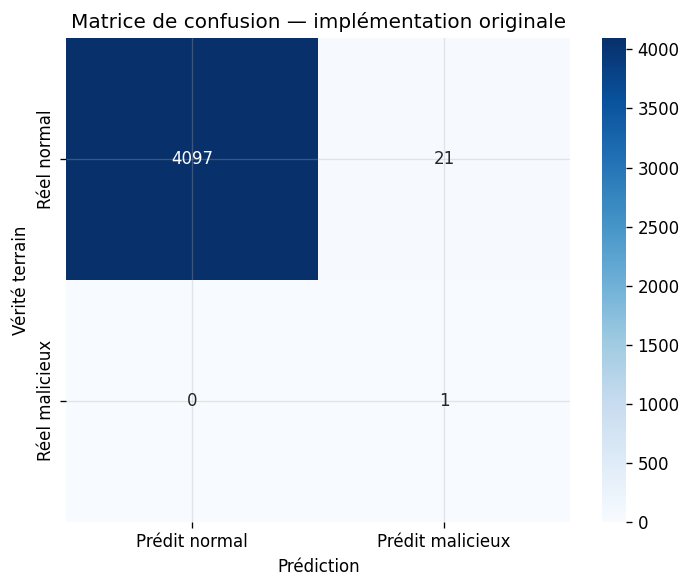

In [21]:
show_saved_figure('confusion_matrix.png')

In [22]:
save_outputs(
    CONFIG,
    train_features=train_features,
    val_features=val_features,
    test_results=test_results,
    metrics=metrics,
    best_thresholds=best_thresholds,
    report=report,
)

pd.Series(
    {
        'results_dir': CONFIG['results_dir'],
        'metrics_path': str(Path(CONFIG['results_dir']) / 'metrics.json'),
        'predictions_path': str(Path(CONFIG['results_dir']) / 'predictions.csv'),
    }
)

results_dir                        results/
metrics_path           results\metrics.json
predictions_path    results\predictions.csv
dtype: object

## 7. Récapitulatif final de tous les scores

Cette dernière cellule rassemble tous les scores de l'implémentation originale,
ainsi que les seuils utilisés.

In [23]:
original_recap = pd.Series(
    {
        'ThresholdMajor': best_thresholds['threshold_major'],
        'ThresholdMinor': best_thresholds['threshold_minor'],
        'TP': metrics['TP'],
        'TN': metrics['TN'],
        'FP': metrics['FP'],
        'FN': metrics['FN'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1': metrics['F1'],
        'FPR': metrics['FPR'],
        'Accuracy': metrics['Accuracy'],
        'N_eval': metrics['N_eval'],
        'N_botnet': metrics['N_botnet'],
        'N_normal': metrics['N_normal'],
    },
    name='original_implementation',
)

display(original_recap.to_frame())

,original_implementation
ThresholdMajor,80.606228
ThresholdMinor,123.466488
TP,1.000000
TN,4097.000000
FP,21.000000
FN,0.000000
Precision,0.045455
Recall,1.000000
F1,0.086957
FPR,0.005100
